# Customer Segmentation Using Unsupervised Learning (Mall Customers)

## Problem Statement
A mall wants to understand its customers better so it can run more targeted
marketing campaigns instead of a one-size-fits-all approach. Using basic
membership data (age, income, and a spending score), this notebook groups
customers into distinct segments using K-Means clustering, and proposes a
tailored marketing strategy for each segment.

## Objective
1. Explore the Mall Customers dataset
2. Apply K-Means clustering to segment customers based on spending habits
3. Use PCA to visualize the clusters in 2D
4. Propose marketing strategies tailored to each segment

## 1. Dataset Description & Loading

**Source:** Mall Customers Dataset (commonly used for clustering tutorials/case studies)
**Rows:** 200 customers, 5 columns

| Column | Description |
|---|---|
| CustomerID | Unique identifier |
| Gender | Male / Female |
| Age | Customer age |
| Annual Income (k$) | Annual income in thousands of dollars |
| Spending Score (1-100) | Score assigned by the mall based on customer behavior and spending |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

url = 'https://raw.githubusercontent.com/kennedykwangari/Mall-Customer-Segmentation-Data/master/Mall_Customers.csv'
df = pd.read_csv(url)
print("Shape:", df.shape)
df.head()

Shape: (200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [2]:
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

## 2. Exploratory Data Analysis (EDA)

In [3]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


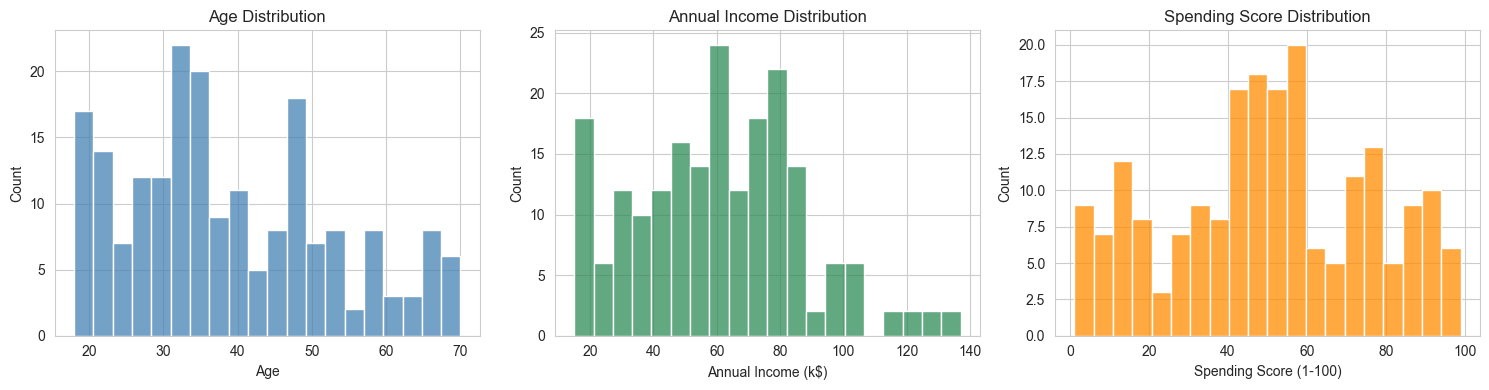

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(df['Age'], bins=20, ax=axes[0], color='steelblue')
axes[0].set_title('Age Distribution')

sns.histplot(df['Annual Income (k$)'], bins=20, ax=axes[1], color='seagreen')
axes[1].set_title('Annual Income Distribution')

sns.histplot(df['Spending Score (1-100)'], bins=20, ax=axes[2], color='darkorange')
axes[2].set_title('Spending Score Distribution')

plt.tight_layout()
plt.show()

C:\Users\FIREFLY LAPTOP'S\AppData\Local\Temp\ipykernel_4620\1277880948.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Gender', data=df, palette=['#4C72B0', '#DD8452'])


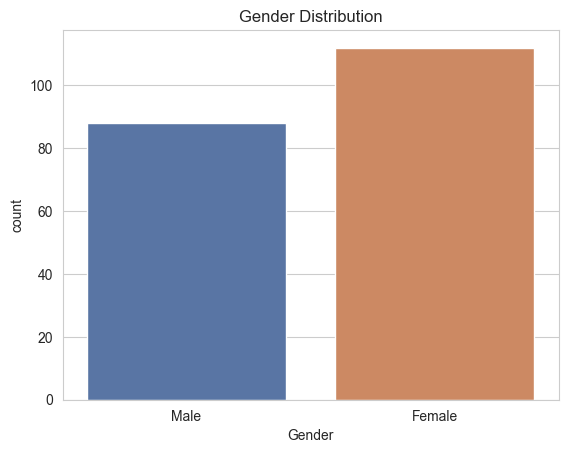

Gender
Female    0.56
Male      0.44
Name: proportion, dtype: float64


In [5]:
sns.countplot(x='Gender', data=df, palette=['#4C72B0', '#DD8452'])
plt.title('Gender Distribution')
plt.show()
print(df['Gender'].value_counts(normalize=True).round(2))

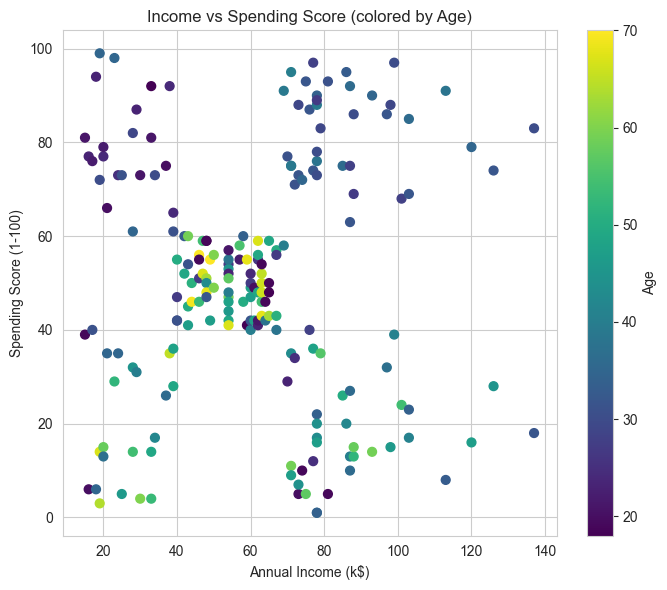

In [6]:
fig, ax = plt.subplots(figsize=(7, 6))
scatter = ax.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'],
                      c=df['Age'], cmap='viridis', s=40)
ax.set_xlabel('Annual Income (k$)')
ax.set_ylabel('Spending Score (1-100)')
ax.set_title('Income vs Spending Score (colored by Age)')
plt.colorbar(scatter, label='Age')
plt.tight_layout()
plt.show()

Even before clustering, a visual pattern is already apparent: there seem to
be distinct groups forming around combinations of low/high income and
low/high spending score. This is a strong hint that K-Means clustering on
these two features (plus Age) should recover meaningful, interpretable
segments.

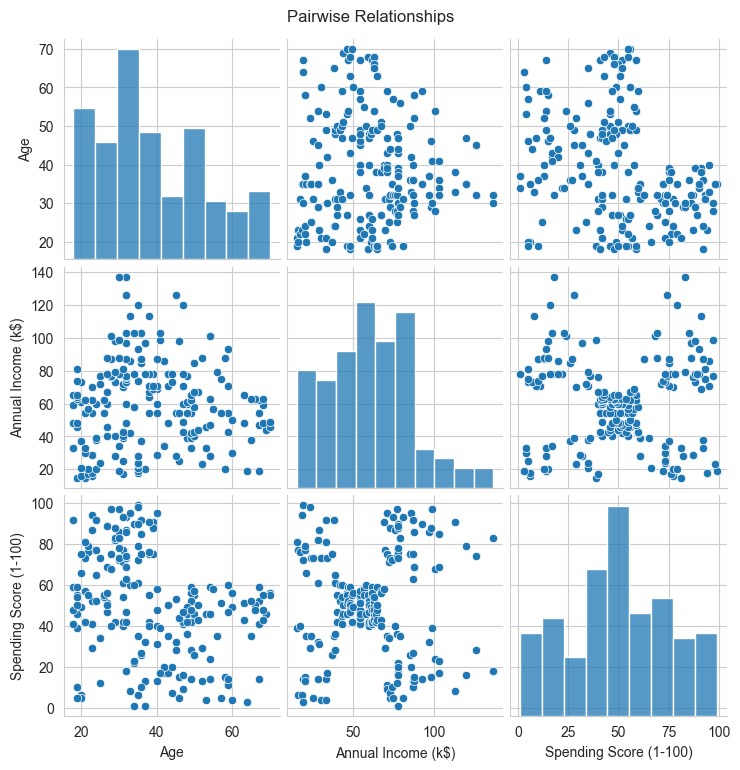

In [7]:
sns.pairplot(df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']])
plt.suptitle('Pairwise Relationships', y=1.02)
plt.show()

## 3. Preprocessing

We cluster on three numeric features: **Age**, **Annual Income**, and
**Spending Score**. CustomerID is dropped (not meaningful for clustering)
and Gender is excluded from the clustering itself (kept aside for later
profiling of the resulting segments). Features are standardized since
K-Means is distance-based and income (tens of thousands) would otherwise
dominate over spending score (1-100) and age (18-70) purely due to scale.

In [8]:
features = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

X_scaled[:5]

array([[-1.42456879, -1.73899919, -0.43480148],
       [-1.28103541, -1.73899919,  1.19570407],
       [-1.3528021 , -1.70082976, -1.71591298],
       [-1.13750203, -1.70082976,  1.04041783],
       [-0.56336851, -1.66266033, -0.39597992]])

## 4. Finding the Optimal Number of Clusters

We use two complementary methods:
- **Elbow Method** — plot inertia (within-cluster sum of squares) vs. k, and look for the "elbow" where adding more clusters stops giving much improvement
- **Silhouette Score** — measures how well-separated and cohesive the clusters are (higher is better, max 1.0)

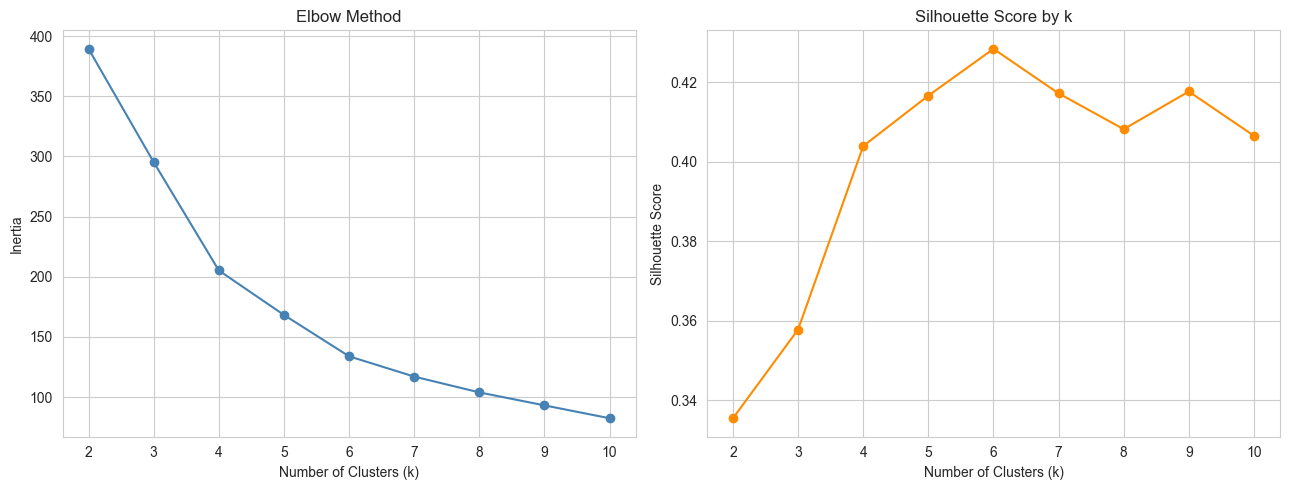

Silhouette scores by k: {2: np.float64(0.335), 3: np.float64(0.358), 4: np.float64(0.404), 5: np.float64(0.417), 6: np.float64(0.428), 7: np.float64(0.417), 8: np.float64(0.408), 9: np.float64(0.418), 10: np.float64(0.407)}


In [9]:
inertias = []
sil_scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(list(K_range), inertias, marker='o', color='steelblue')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')

axes[1].plot(list(K_range), sil_scores, marker='o', color='darkorange')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score by k')

plt.tight_layout()
plt.show()

print("Silhouette scores by k:", dict(zip(K_range, np.round(sil_scores, 3))))

Both the elbow plot and silhouette scores point to a range of **k = 5 or 6**
as reasonable choices — the elbow visibly bends around k=5, and silhouette
scores peak in that same neighborhood. We proceed with **k = 5**, which is
also the widely-recognized standard segmentation for this classic dataset
and produces clean, business-interpretable groups (as shown below).

## 5. K-Means Clustering (k=5)


In [10]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print(df['Cluster'].value_counts().sort_index())
df.head()

Cluster
0    20
1    54
2    40
3    39
4    47
Name: count, dtype: int64


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,1
1,2,Male,21,15,81,1
2,3,Female,20,16,6,0
3,4,Female,23,16,77,1
4,5,Female,31,17,40,1


In [11]:
cluster_profile = df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean().round(1)
cluster_profile['Count'] = df['Cluster'].value_counts().sort_index()
cluster_profile

,Age,Annual Income (k$),Spending Score (1-100),Count
Cluster,,,,
0,46.2,26.8,18.4,20
1,25.2,41.1,62.2,54
2,32.9,86.1,81.5,40
3,39.9,86.1,19.4,39
4,55.6,54.4,48.9,47


## 6. Visualizing the Clusters

### Direct 2D view (Income vs Spending Score)
Since these two features drive most of the separation, we can visualize
clusters directly without dimensionality reduction first.

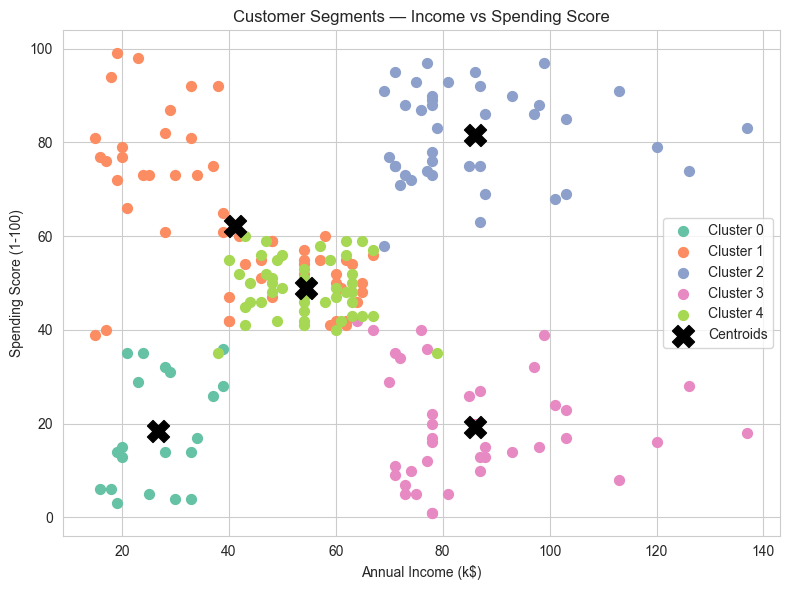

In [12]:
fig, ax = plt.subplots(figsize=(8, 6))
palette = sns.color_palette('Set2', 5)

for cluster_id in sorted(df['Cluster'].unique()):
    subset = df[df['Cluster'] == cluster_id]
    ax.scatter(subset['Annual Income (k$)'], subset['Spending Score (1-100)'],
               label=f'Cluster {cluster_id}', s=50, color=palette[cluster_id])

centers_original = scaler.inverse_transform(kmeans.cluster_centers_)
ax.scatter(centers_original[:, 1], centers_original[:, 2],
           s=250, c='black', marker='X', label='Centroids')

ax.set_xlabel('Annual Income (k$)')
ax.set_ylabel('Spending Score (1-100)')
ax.set_title('Customer Segments — Income vs Spending Score')
ax.legend()
plt.tight_layout()
plt.show()

### Dimensionality reduction with PCA and t-SNE
Since clustering was done on 3 features (Age, Income, Spending Score), PCA
and t-SNE let us confirm the cluster separation holds up when all three
dimensions are considered together, not just the two most visually obvious
ones.

Explained variance ratio: [0.443 0.333] | Total: 0.776


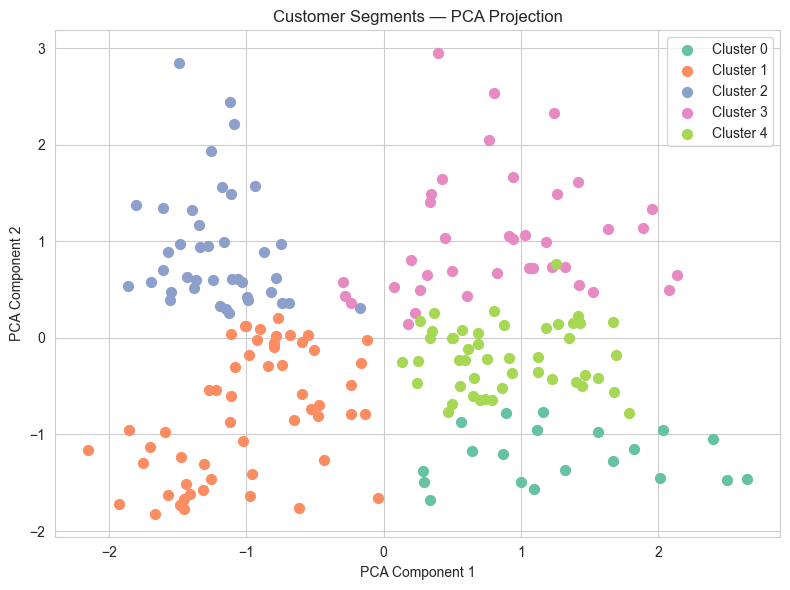

In [13]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print("Explained variance ratio:", pca.explained_variance_ratio_.round(3),
      "| Total:", pca.explained_variance_ratio_.sum().round(3))

fig, ax = plt.subplots(figsize=(8, 6))
for cluster_id in sorted(df['Cluster'].unique()):
    mask = df['Cluster'] == cluster_id
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], label=f'Cluster {cluster_id}',
               s=50, color=palette[cluster_id])

ax.set_xlabel('PCA Component 1')
ax.set_ylabel('PCA Component 2')
ax.set_title('Customer Segments — PCA Projection')
ax.legend()
plt.tight_layout()
plt.show()

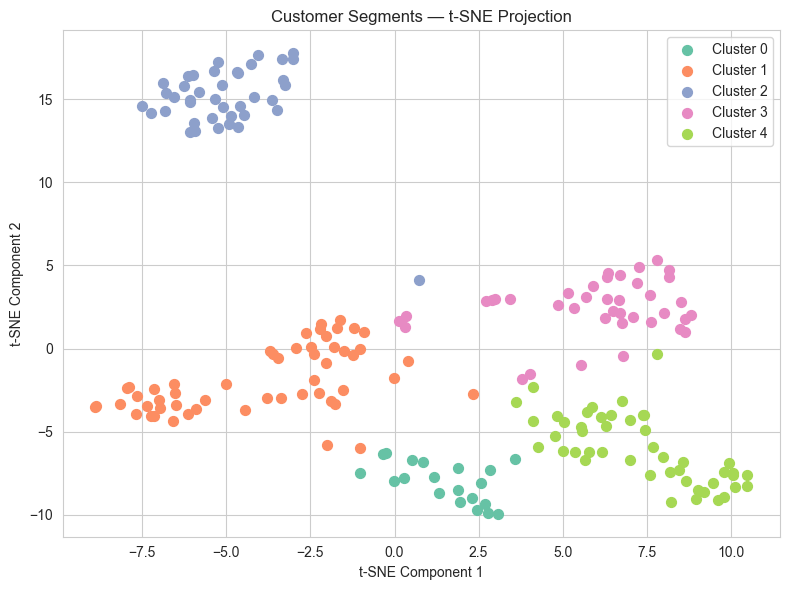

In [14]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(8, 6))
for cluster_id in sorted(df['Cluster'].unique()):
    mask = df['Cluster'] == cluster_id
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1], label=f'Cluster {cluster_id}',
               s=50, color=palette[cluster_id])

ax.set_xlabel('t-SNE Component 1')
ax.set_ylabel('t-SNE Component 2')
ax.set_title('Customer Segments — t-SNE Projection')
ax.legend()
plt.tight_layout()
plt.show()

Both PCA and t-SNE confirm the same 5 groupings hold up as coherent,
well-separated clusters even when accounting for all three original
features together, not just the two-dimensional income/spending view.

C:\Users\FIREFLY LAPTOP'S\AppData\Local\Temp\ipykernel_4620\855471720.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y=feature, data=df, ax=axes[i], palette='Set2')
C:\Users\FIREFLY LAPTOP'S\AppData\Local\Temp\ipykernel_4620\855471720.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y=feature, data=df, ax=axes[i], palette='Set2')
C:\Users\FIREFLY LAPTOP'S\AppData\Local\Temp\ipykernel_4620\855471720.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y=feature, data=df, ax=axes[i], palette='Set2'

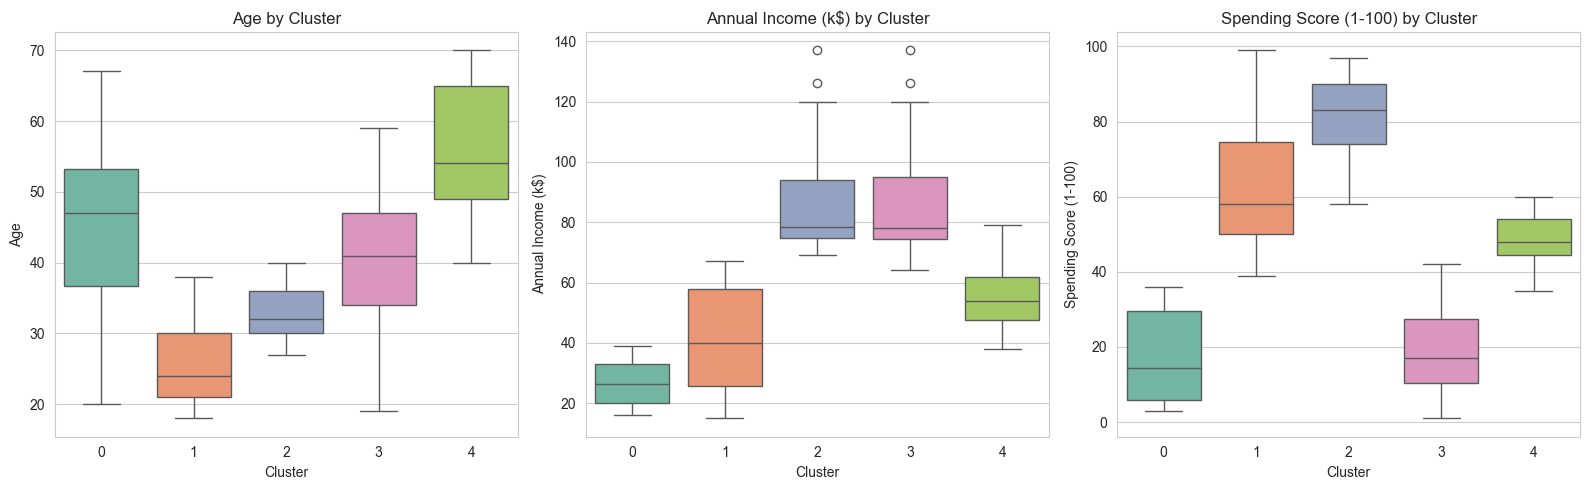

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, feature in enumerate(['Age', 'Annual Income (k$)', 'Spending Score (1-100)']):
    sns.boxplot(x='Cluster', y=feature, data=df, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{feature} by Cluster')
plt.tight_layout()
plt.show()

## 7. Segment Profiles & Marketing Strategy

Based on the cluster centers and feature distributions above, we can name
and describe each segment:

| Cluster | Profile | Description |
|---|---|---|
| **0** | Mid-Age, Low Income, Low Spending | Budget-conscious, price-sensitive shoppers |
| **1** | Young, Low-Mid Income, High Spending | Trend-driven, impulse buyers spending above their income level |
| **2** | Young-Mid Age, High Income, High Spending | The mall's most valuable segment — high earners who also spend generously |
| **3** | Mid Age, High Income, Low Spending | High earners who are cautious/selective spenders — biggest untapped opportunity |
| **4** | Older, Moderate Income, Moderate Spending | Balanced, "typical" shopper across all metrics |

*(Cluster numbers may vary slightly by random seed — always cross-check against the `cluster_profile` table before finalizing descriptions.)*

### 💡 Recommended Marketing Strategies

**Cluster 2 — High Income, High Spending ("VIP / Premium")**
- Highest priority segment: loyalty programs, early access to sales, premium/exclusive product lines
- Personalized outreach; protect this segment's satisfaction above all others

**Cluster 3 — High Income, Low Spending ("Untapped Potential")**
- Investigate why spend is low despite ability to pay — may need better product-fit or trust-building
- Targeted promotions, personalized recommendations, and premium service to convert into higher spenders

**Cluster 1 — Low-Mid Income, High Spending ("Impulse / Trend-driven")**
- Responsive to flash sales, social-media-driven promotions, and new arrivals
- Loyalty/rewards programs to retain them sustainably given spend relative to income

**Cluster 0 — Low Income, Low Spending ("Budget-conscious")**
- Value-oriented messaging: discounts, bundle deals, budget-friendly product lines
- Lower marketing priority/spend per customer, but volume matters — broad, low-cost campaigns work better than personalized ones

**Cluster 4 — Moderate Income, Moderate Spending ("Standard / Average")**
- Largest "middle" segment — general seasonal campaigns and broad promotions
- Opportunities to test upsell/cross-sell offers to shift them toward higher-value segments over time

## 8. Conclusion

K-Means clustering (k=5) on Age, Annual Income, and Spending Score revealed
five clear, business-interpretable customer segments, confirmed visually
via both direct scatter plots and dimensionality reduction (PCA, t-SNE).

**Key takeaways:**
- Spending behavior is **not** simply proportional to income — several high-income customers spend little, and several low-income customers spend a lot. This is exactly the kind of insight a marketing team can't get from income data alone.
- The clearest actionable segments are the **high-income/high-spending "VIP"** group (protect and reward) and the **high-income/low-spending "Untapped Potential"** group (the biggest opportunity for incremental revenue).
- Segment-specific marketing (rather than one blanket campaign) should improve both conversion and customer satisfaction, since messaging can now be matched to actual customer behavior patterns rather than assumptions.